# NFHS-5 Nutrition Analysis

This notebook explores nutritional indicators across Indian states and districts using NFHS-5 data.

Objectives:

- Study anaemia prevalence among children and women.
- Analyze underweight and overweight prevalence among children.
- Examine women with BMI below the normal range.
- Compare states and districts.
- Identify nutritional disparities and patterns.
- Explore relationships between different nutrition indicators.

In [1]:
import pandas as pd 
df_clean=pd.read_csv("nfhs5_cleaned_final.csv" )
df_clean.shape

(704, 106)

##  Setting up the Nutrition Theme 

In [2]:
nutrition_cols = [
    col for col in df_clean.columns
    if any(keyword in col for keyword in [
        "obese",
        "overweight",
        "bmi",
        "waist",
        "diet",
        "breastfed",
        "feeding",
        "nutrition",
        "underweight",
        "stunting",
        "wasting",
        "anaemic",
        "below"
    ])
]

In [3]:
## nutrition_cols

In [4]:
nutrition_cols = [
    "women_age_group_15_to_19_years_who_are_anaemic",
    "women_age_group_15_to_49_years_who_are_anaemic",
    "non_pregnant_women_age_group_15_to_49_years_who_are_anaemic",
    "pregnant_women_age_group_15_to_49_years_who_are_anaemic",
    "children_age_group_6_to_59_months_who_are_anaemic",
    "breastfeeding_children_age_group_6_to_23_months_receiving_an_adequate_diet",
    "children_under_age_3_years_breastfed_within_one_hour_of_birth",
    "children_under_age_6_months_exclusively_breastfed",
    "children_age_group_6_to_23_months_receiving_an_adequate_diet",
    "children_under_5_years_who_are_overweight",
    "children_under_5_years_who_are_underweight",
    "women_who_are_overweight_or_obese",
    "women_with_body_mass_index_below_normal",
    "women_who_have_high_risk_waist_to_hip_ratio"
]

In [5]:
##len(nutrition_cols)

In [6]:
## Urban and rural check !! 
##[col for col in df_clean.columns if "urban" in col or "rural" in col]

## Nutrition Theme Analysis

## Descriptive Stats

In [7]:
## summary stats 
df_clean[nutrition_cols].describe()

,women_age_group_15_to_19_years_who_are_anaemic,women_age_group_15_to_49_years_who_are_anaemic,non_pregnant_women_age_group_15_to_49_years_who_are_anaemic,pregnant_women_age_group_15_to_49_years_who_are_anaemic,children_age_group_6_to_59_months_who_are_anaemic,breastfeeding_children_age_group_6_to_23_months_receiving_an_adequate_diet,children_under_age_3_years_breastfed_within_one_hour_of_birth,children_under_age_6_months_exclusively_breastfed,children_age_group_6_to_23_months_receiving_an_adequate_diet,children_under_5_years_who_are_overweight,children_under_5_years_who_are_underweight,women_who_are_overweight_or_obese,women_with_body_mass_index_below_normal,women_who_have_high_risk_waist_to_hip_ratio
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,58.244318,56.056392,56.305540,45.345597,65.898153,11.905966,44.754972,49.621307,12.308381,4.199858,29.557244,22.984233,17.922017,57.445312
std,12.805283,11.880863,11.952572,20.008731,12.043212,7.733884,16.225149,29.566915,7.479417,3.105094,9.715836,10.561492,7.431710,13.872469
min,18.200000,14.900000,15.600000,0.000000,24.900000,0.000000,7.800000,0.000000,0.000000,0.000000,7.200000,3.800000,1.200000,18.000000
25%,50.650000,49.300000,49.475000,37.175000,59.600000,6.100000,32.500000,36.700000,6.700000,2.200000,22.100000,14.900000,12.700000,48.775000
50%,59.800000,57.250000,57.500000,49.000000,67.700000,10.200000,45.050000,60.800000,10.800000,3.450000,29.500000,21.250000,18.000000,58.050000
75%,66.625000,63.725000,64.025000,59.325000,74.025000,16.025000,56.500000,69.975000,16.725000,5.400000,36.300000,29.800000,23.100000,67.100000
max,97.100000,93.500000,94.600000,87.600000,95.500000,54.100000,88.500000,94.000000,50.100000,21.100000,62.400000,53.000000,43.600000,96.600000


## Histogram of all Nutrition Columns

In [8]:
##df_clean[nutrition_cols].hist(figsize=(16, 10), bins=20)

## working with only Anameic columns

In [9]:
anaemic_cols = [
    "women_age_group_15_to_19_years_who_are_anaemic",
    "women_age_group_15_to_49_years_who_are_anaemic",
    "non_pregnant_women_age_group_15_to_49_years_who_are_anaemic",
    "pregnant_women_age_group_15_to_49_years_who_are_anaemic",
    "children_age_group_6_to_59_months_who_are_anaemic"
]

## Distribution of Anaemic columns

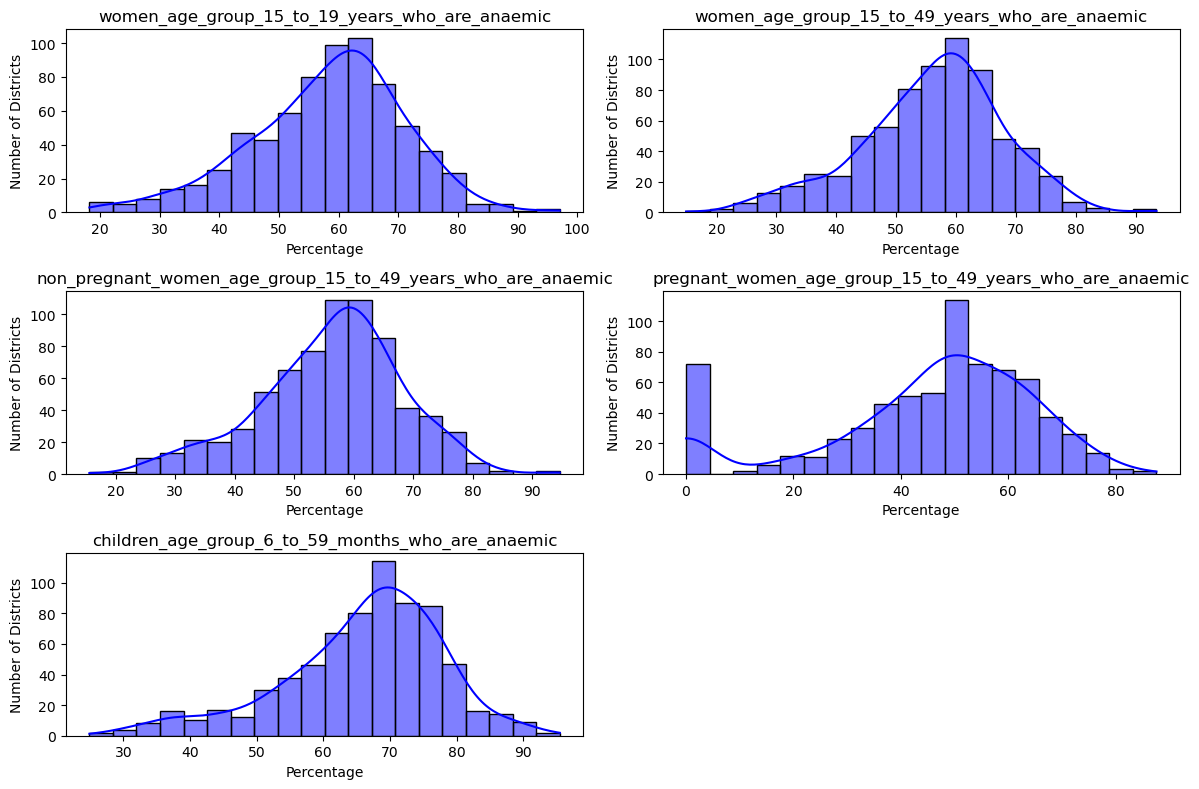

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, col in enumerate(anaemic_cols, 1):
    plt.subplot(3, 2, i)
    
    sns.histplot(
        df_clean[col],
        bins=20,
        kde=True , color="blue"
    )
    
    plt.title(col)
    plt.xlabel("Percentage")
    plt.ylabel("Number of Districts")

plt.tight_layout()
plt.show()

In [11]:
df_clean[anaemic_cols].mean().sort_values(ascending=False)

children_age_group_6_to_59_months_who_are_anaemic              65.898153
women_age_group_15_to_19_years_who_are_anaemic                 58.244318
non_pregnant_women_age_group_15_to_49_years_who_are_anaemic    56.305540
women_age_group_15_to_49_years_who_are_anaemic                 56.056392
pregnant_women_age_group_15_to_49_years_who_are_anaemic        45.345597
dtype: float64

## Most effected population is of children who are anaemic

### Top and Bottom Performing States

This analysis compares the top 10 and bottom 10 states based on the selected nutrition indicator. The comparison provides a quick overview of interstate variation and helps identify states with relatively higher and lower prevalence levels.

In [12]:
df_clean.sort_values(
    "children_age_group_6_to_59_months_who_are_anaemic",
    ascending=False
)[["state",
   "district",
   "children_age_group_6_to_59_months_who_are_anaemic"]].head(10)

,state,district,children_age_group_6_to_59_months_who_are_anaemic
303,Ladakh,Leh Ladakh,95.5
168,Gujarat,Narmada,93.2
130,Chhattisgarh,Sukma,91.4
208,Himachal Pradesh,Lahul And Spiti,91.0
170,Gujarat,Panch Mahals,91.0
114,Chhattisgarh,Dakshin Bastar Dantewada,89.9
219,Jammu And Kashmir,Ganderbal,89.8
30,Arunachal Pradesh,Tawang,89.6
150,Gujarat,Arvalli,89.5
18,Arunachal Pradesh,Dibang Valley,88.6


In [13]:
df_clean.sort_values(
    "children_age_group_6_to_59_months_who_are_anaemic"
)[["state",
   "district",
   "children_age_group_6_to_59_months_who_are_anaemic"]].head(10)

,state,district,children_age_group_6_to_59_months_who_are_anaemic
29,Arunachal Pradesh,Siang,24.9
398,Meghalaya,East Garo Hills,28.0
406,Meghalaya,West Garo Hills,30.2
401,Meghalaya,North Garo Hills,30.2
288,Kerala,Alappuzha,30.3
1,Andaman And Nicobar Islands,North And Middle Andaman,30.4
290,Kerala,Idukki,32.0
295,Kerala,Kozhikode,32.1
293,Kerala,Kollam,32.5
299,Kerala,Thiruvananthapuram,33.0


### Observations

- Large district-level variation is observed, ranging from 24.9% in Siang (Arunachal Pradesh) to 95.5% in Leh Ladakh.
- Several districts from Gujarat, Chhattisgarh, and Arunachal Pradesh appear among the highest-ranked districts.
- Kerala and Meghalaya account for many of the lowest-ranked districts.
- The wide gap between the highest and lowest values highlights substantial regional disparities across India.

## Maharashtra Analysis

This section focuses on district-level variation within Maharashtra, providing a closer look at how the selected nutrition indicator differs across districts of the state.

In [14]:
mh_data = df_clean[df_clean["state"] == "Maharashtra"]

In [15]:
mh_data["children_age_group_6_to_59_months_who_are_anaemic"].describe()

count    35.000000
mean     70.474286
std       6.492455
min      55.600000
25%      67.150000
50%      70.500000
75%      75.300000
max      85.200000
Name: children_age_group_6_to_59_months_who_are_anaemic, dtype: float64

###

- The average value across Maharashtra districts is 70.5%.
- Values range from 55.6% to 85.2%, indicating moderate district-level variation.
- The mean and median are nearly identical, suggesting a fairly balanced distribution.

In [16]:
mh_data.sort_values(
    "children_age_group_6_to_59_months_who_are_anaemic",
    ascending=False
)[["district",
   "children_age_group_6_to_59_months_who_are_anaemic"]].head(10)

,district,children_age_group_6_to_59_months_who_are_anaemic
367,Jalgaon,85.2
359,Buldhana,79.4
374,Nandurbar,79.3
365,Gondia,78.0
355,Akola,77.5
360,Chandrapur,76.6
364,Gadchiroli,76.6
373,Nanded,76.1
377,Parbhani,75.4
388,Yavatmal,75.2


In [17]:
mh_data.sort_values(
    "children_age_group_6_to_59_months_who_are_anaemic"
)[["district",
   "children_age_group_6_to_59_months_who_are_anaemic"]].head(10)

,district,children_age_group_6_to_59_months_who_are_anaemic
383,Sindhudurg,55.6
378,Pune,58.7
370,Latur,59.5
357,Beed,61.0
381,Sangli,62.7
361,Chhatrapati Sambhajinagar,64.5
354,Ahmednagar,64.5
369,Kolhapur,66.4
379,Raigad,67.0
375,Nashik,67.3


### Observations

- Jalgaon records the highest value (85.2%), followed by Buldhana and Nandurbar.
- Sindhudurg has the lowest value (55.6%), with Pune and Latur also among the lower-ranked districts.
- Jalgaon's value is 14.7 percentage points above the Maharashtra district average (70.5%), highlighting its relatively high prevalence.
- The gap of nearly 30 percentage points between the highest and lowest districts indicates notable variation across Maharashtra.

# Underweight Children Analysis

This section examines the prevalence of underweight children across Indian states and districts using NFHS-5 data. The analysis aims to identify regional disparities and highlight areas with relatively high and low prevalence levels.

In [18]:
df_clean["children_under_5_years_who_are_underweight"].describe()
#df_clean["children_under_5_years_who_are_underweight"].hist()


count    704.000000
mean      29.557244
std        9.715836
min        7.200000
25%       22.100000
50%       29.500000
75%       36.300000
max       62.400000
Name: children_under_5_years_who_are_underweight, dtype: float64

 ### Observations

- The average prevalence of underweight children across districts is 29.6%.
- Values range from 7.2% to 62.4%, indicating substantial variation across districts.
- The mean (29.6%) and median (29.5%) are nearly identical, suggesting no strong skewness in the distribution.

## States with Highest and Lowest underweight prevalence

In [19]:
(df_clean.groupby("state")[
    "children_under_5_years_who_are_underweight"
].mean().sort_values(ascending=False).head(10))

state
Bihar                                           41.726316
Jharkhand                                       40.400000
Gujarat                                         40.330303
Maharashtra                                     36.774286
The Dadra And Nagar Haveli And Daman And Diu    33.300000
Chhattisgarh                                    33.218519
Madhya Pradesh                                  33.156000
Telangana                                       32.890625
West Bengal                                     32.700000
Uttar Pradesh                                   32.317333
Name: children_under_5_years_who_are_underweight, dtype: float64

In [20]:
(df_clean.groupby("state")[
    "children_under_5_years_who_are_underweight"
].mean().sort_values().head(10))

state
Mizoram              13.650000
Sikkim               13.700000
Manipur              13.766667
Arunachal Pradesh    14.115000
Punjab               17.659091
Uttarakhand          19.161538
Kerala               19.371429
Ladakh               20.400000
Haryana              20.913636
Puducherry           21.025000
Name: children_under_5_years_who_are_underweight, dtype: float64

## Maharashtra Analysis

In [21]:
maharashtra_data = df_clean[
    df_clean["state"] == "Maharashtra"
]

## Descriptive Stats for Maharashtra

In [22]:
maharashtra_data["children_under_5_years_who_are_underweight"].describe()
# maharashtra_data["children_under_5_years_who_are_underweight"].hist()


count    35.000000
mean     36.774286
std       6.342589
min      27.200000
25%      32.600000
50%      35.400000
75%      39.350000
max      57.200000
Name: children_under_5_years_who_are_underweight, dtype: float64

### Observations

- The average prevalence of underweight children across Maharashtra districts is 36.8%.
- District values range from 27.2% to 57.2%, indicating noticeable variation across the state.
- The mean (36.8%) and median (35.4%) are relatively close, suggesting no strong skewness in the distribution.

## Districts with Highest and lowest underweight prevalence

In [23]:
maharashtra_data.groupby("district")[
    "children_under_5_years_who_are_underweight"
].mean().sort_values(ascending=False).head(10)

district
Nandurbar                    57.2
Buldhana                     47.2
Chandrapur                   46.6
Dhule                        46.0
Nashik                       44.8
Chhatrapati Sambhajinagar    42.9
Parbhani                     41.8
Ahmednagar                   41.2
Yavatmal                     39.4
Washim                       39.3
Name: children_under_5_years_who_are_underweight, dtype: float64

In [25]:
best_districts = maharashtra_data.groupby("district")[
    "children_under_5_years_who_are_underweight"
].mean().sort_values().head(10)

best_districts

district
Sangli        27.2
Satara        28.0
Ratnagiri     29.5
Mumbai        29.6
Akola         30.8
Thane         30.8
Wardha        31.3
Sindhudurg    32.0
Dharashiv     32.5
Pune          32.7
Name: children_under_5_years_who_are_underweight, dtype: float64

In [29]:
top_districts=maharashtra_data.groupby("district")["children_under_5_years_who_are_underweight"].mean().sort_values(ascending=False).head(10)
state_avg = maharashtra_data[
    "children_under_5_years_who_are_underweight"
].mean()

district_avg = top_districts.iloc[0]

print("Maharashtra average:", state_avg)
print("Highest district:", district_avg)

Maharashtra average: 36.77428571428571
Highest district: 57.2



## Nandurbar reports a prevalence of 57.2%, exceeding the Maharashtra average (36.8%) by approximately 20 percentage points, highlighting a considerably higher burden of underweight children in the district.

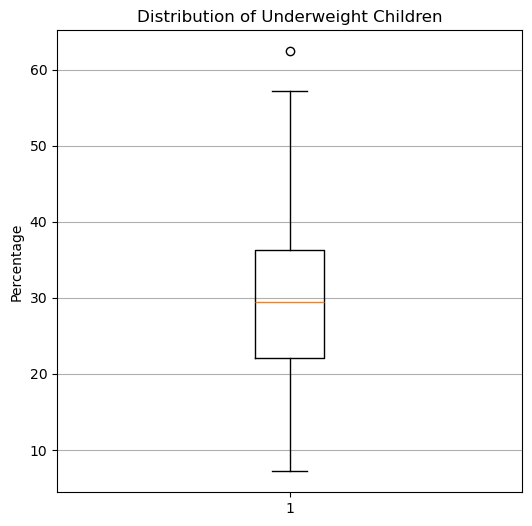

In [30]:
## box plot 
plt.figure(figsize=(6, 6))

plt.boxplot(
    df_clean[
        "children_under_5_years_who_are_underweight"
    ]
)

plt.title("Distribution of Underweight Children")

plt.ylabel("Percentage")

plt.grid(axis="y")

plt.show()

## The boxplot indicates that underweight prevalence varies across districts, but most districts cluster around 30%, with a few extreme districts experiencing significantly higher levels of undernutrition.

## Overweight Children Analysis

In [31]:
overweight_state = df_clean.groupby("state")[
    "children_under_5_years_who_are_overweight"
].mean().sort_values(ascending=False)

overweight_state

state
Ladakh                                          13.350000
Sikkim                                          10.925000
Jammu And Kashmir                               10.695000
Arunachal Pradesh                               10.090000
Mizoram                                          9.425000
Tripura                                          7.700000
Himachal Pradesh                                 6.241667
Assam                                            4.909091
Nagaland                                         4.800000
Tamil Nadu                                       4.528125
Maharashtra                                      4.460000
Chhattisgarh                                     4.440741
Delhi                                            4.400000
Uttarakhand                                      4.307692
Puducherry                                       4.300000
Kerala                                           4.185714
West Bengal                                      4.170000
Punjab  

In [32]:
df_clean[
    "children_under_5_years_who_are_overweight"
].mean()    ## natianal average

4.199857954545454

## The prevalence of overweight children is relatively low across India, while underweight prevalence remains substantially higher, suggesting that undernutrition is the more pressing public health concern.

# Women with Low BMI Analysis

Body Mass Index (BMI) is a commonly used indicator of nutritional status. A low BMI may indicate undernutrition and can be associated with adverse health outcomes among women.
This section analyzes the prevalence of women with a BMI below the normal range across states and districts, highlighting regional disparities and areas with a higher burden of undernutrition.

## Descriptive Stats

In [33]:
df_clean["women_with_body_mass_index_below_normal"].describe()
#df_clean["women_with_body_mass_index_below_normal"].hist()



count    704.000000
mean      17.922017
std        7.431710
min        1.200000
25%       12.700000
50%       18.000000
75%       23.100000
max       43.600000
Name: women_with_body_mass_index_below_normal, dtype: float64

In [34]:
women_bmi_state = df_clean.groupby("state")[
    "women_with_body_mass_index_below_normal"
].mean().sort_values(ascending=False)

women_bmi_state.head(10)

state
Jharkhand                                       26.925000
Gujarat                                         26.006061
Bihar                                           25.876316
Chhattisgarh                                    24.985185
Madhya Pradesh                                  23.506000
Maharashtra                                     21.980000
The Dadra And Nagar Haveli And Daman And Diu    21.900000
Odisha                                          21.856667
Rajasthan                                       20.172727
Telangana                                       19.971875
Name: women_with_body_mass_index_below_normal, dtype: float64

## The prevalence of women with BMI below the normal range varies across states, with Jharkhand reporting the highest level at approximately 26.9%. Maharashtra shows a moderate prevalence of about 22%, indicating a substantial proportion of women experiencing undernutrition.

## Maharashtra State Analysis

In [35]:
district_bmi = maharashtra_data.groupby("district")[
    "women_with_body_mass_index_below_normal"
].mean().sort_values(ascending=False)

district_bmi.head(10)

district
Nandurbar     36.1
Palghar       27.9
Chandrapur    26.5
Dhule         26.5
Bhandara      25.8
Ratnagiri     25.8
Nashik        25.6
Hingoli       24.9
Gadchiroli    24.3
Latur         24.2
Name: women_with_body_mass_index_below_normal, dtype: float64

## Nandurbar consistently shows the highest prevalence of undernutrition across multiple indicators, including underweight children and women with low BMI. This suggests that the district faces persistent nutritional challenges affecting both children and adults.

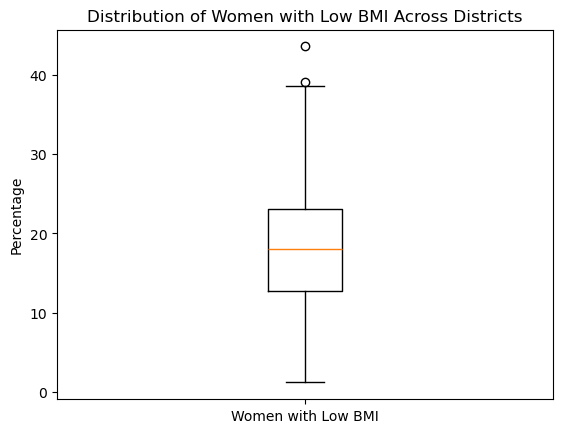

In [36]:
plt.figure()

plt.boxplot(
    df_clean["women_with_body_mass_index_below_normal"]
)

plt.title("Distribution of Women with Low BMI Across Districts")

plt.ylabel("Percentage")

plt.xticks([1], ["Women with Low BMI"])

plt.show()

##  The boxplot shows that the median prevalence of women with BMI below the normal range is approximately 18%, indicating that a typical district has around this level of undernutrition. Most districts fall within the range of 13% to 25%, suggesting moderate variation across regions. A small number of districts exhibit unusually high values above 40%, highlighting localized areas with higher nutritional risk.

## Correlation  Analysis between indicators studied above

In [37]:
worked_cols = [
    "children_under_5_years_who_are_underweight",
    "children_under_5_years_who_are_overweight",
    "women_with_body_mass_index_below_normal",
    "children_age_group_6_to_59_months_who_are_anaemic"
]

corr_matrix = df_clean[worked_cols].corr()

corr_matrix

,children_under_5_years_who_are_underweight,children_under_5_years_who_are_overweight,women_with_body_mass_index_below_normal,children_age_group_6_to_59_months_who_are_anaemic
children_under_5_years_who_are_underweight,1.000000,-0.397541,0.743980,0.404202
children_under_5_years_who_are_overweight,-0.397541,1.000000,-0.484232,-0.021187
women_with_body_mass_index_below_normal,0.743980,-0.484232,1.000000,0.416867
children_age_group_6_to_59_months_who_are_anaemic,0.404202,-0.021187,0.416867,1.000000


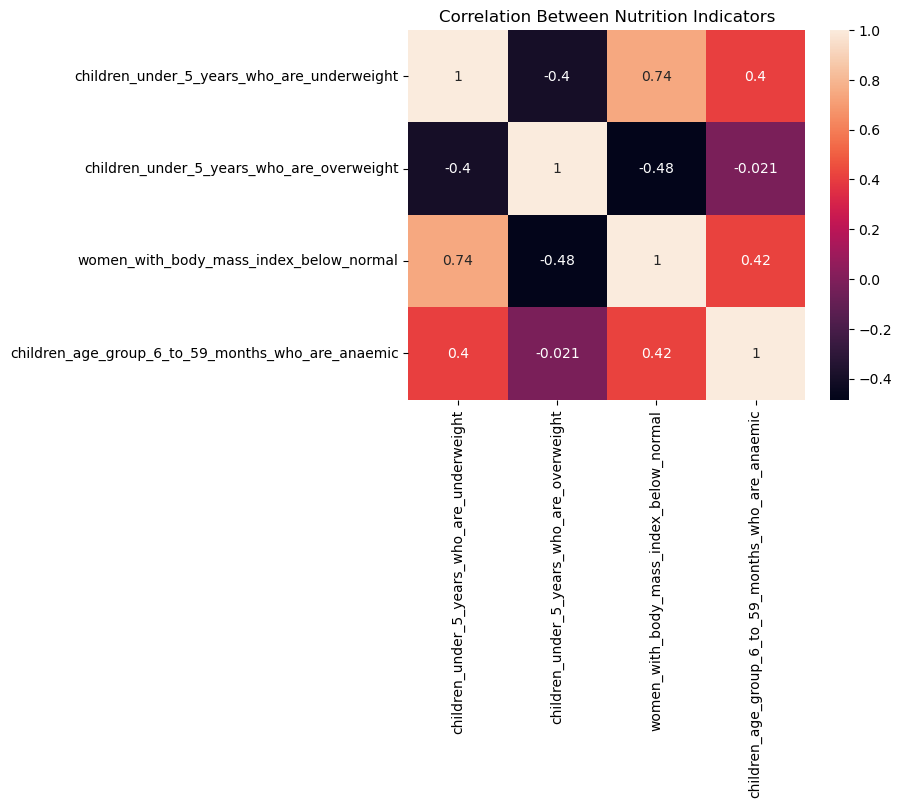

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.heatmap(
    corr_matrix,
    annot=True
)

plt.title("Correlation Between Nutrition Indicators")

plt.show()

## A strong positive correlation (0.74) exists between underweight children and women with low BMI, indicating that districts with higher child undernutrition generally also have higher levels of adult undernutrition.
## A moderate positive correlation (0.40) between underweight children and child anemia suggests that nutritional deficiencies are associated with increased anemia prevalence

# Conclusion

- Children aged 6–59 months showed substantial variation in anaemia prevalence across districts, ranging from 24.9% to 95.5%, highlighting significant regional disparities.
- The prevalence of underweight children ranged from 7.2% to 62.4%, indicating that undernutrition remains a major challenge in several regions.
- Maharashtra recorded an average underweight prevalence of 36.8%, with Nandurbar reporting 57.2%, nearly 20 percentage points above the state average.
- The prevalence of overweight children was generally lower than underweight prevalence, reflecting the continued dominance of undernutrition-related concerns.
- Women with low BMI exhibited considerable variation across states, with Jharkhand recording the highest average prevalence (26.9%), while Maharashtra reported approximately 22%.
- Correlation analysis revealed a strong positive relationship (0.74) between underweight children and women with low BMI, suggesting that child and maternal nutritional outcomes are closely linked.